# 03 — Deformación del lóbulo central vs. contribución cruzada

**Pregunta central.** ¿Cuánto y cómo se aparta el lóbulo central vectorial
del escalar, en función de apertura, índice y forma de pupila? ¿Gobierna la
fracción cruzada $f_{\rm cross}$ esa deformación?

**Teoría a primer orden.** Con $I_{\parallel,\perp}=|H_0\mp H_2|^2$ y
$B(s)=\mathrm{Re}(H_0H_2^*)$, expandiendo alrededor del radio de mitad de
altura escalar $R_{\rm sca}$:

$$ R_{\parallel,\perp} \;\simeq\; R_{\rm sca} \mp
   \frac{2\,B(R_{\rm sca})}{|I_{\rm sca}'(R_{\rm sca})|},
   \qquad
   A_{\rm pred} \;=\; \frac{R_\perp-R_\parallel}{R_{\rm sca}}
   \;\simeq\; \frac{4\,B(R_{\rm sca})}{|I_{\rm sca}'(R_{\rm sca})|\,R_{\rm sca}}. $$

La anisotropía es **de primer orden en $H_2$** y depende del solapamiento
**local** co/cruzada en el radio de mitad de altura; $f_{\rm cross}$ es
**de segundo orden** (energía global $\propto|H_2|^2$). Por lo tanto:

- dentro de una familia de pupilas, $A \propto \sqrt{f_{\rm cross}}$
  aproximadamente;
- entre familias distintas (que reparten $|H_2(q)|$ de otro modo)
  $f_{\rm cross}$ **no** debería determinar la deformación, pero
  $A_{\rm pred}$ sí.

En la incidencia **circular** no hay término de primer orden
($I_{\rm circ}=I_{\rm sca}+|H_2|^2$): el ensanchamiento es de segundo orden
y ahí sí se espera correlación directa con $f_{\rm cross}$.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import spot_tools as st

plt.rcParams.update({"figure.dpi": 110, "font.size": 9})
out_dir = Path("output")
out_dir.mkdir(exist_ok=True)

base = dict(n0=1.0, z0=-10.0, zi=6.0, lam=532e-6)


def evaluate(case):
    m = st.spot_metrics(case)
    m["A_pred"] = st.anisotropy_prediction(case)
    m["alpha_obj_deg"] = case["alpha_obj_deg"]
    return m

## 1. Atlas apertura × índice (pupila uniforme)

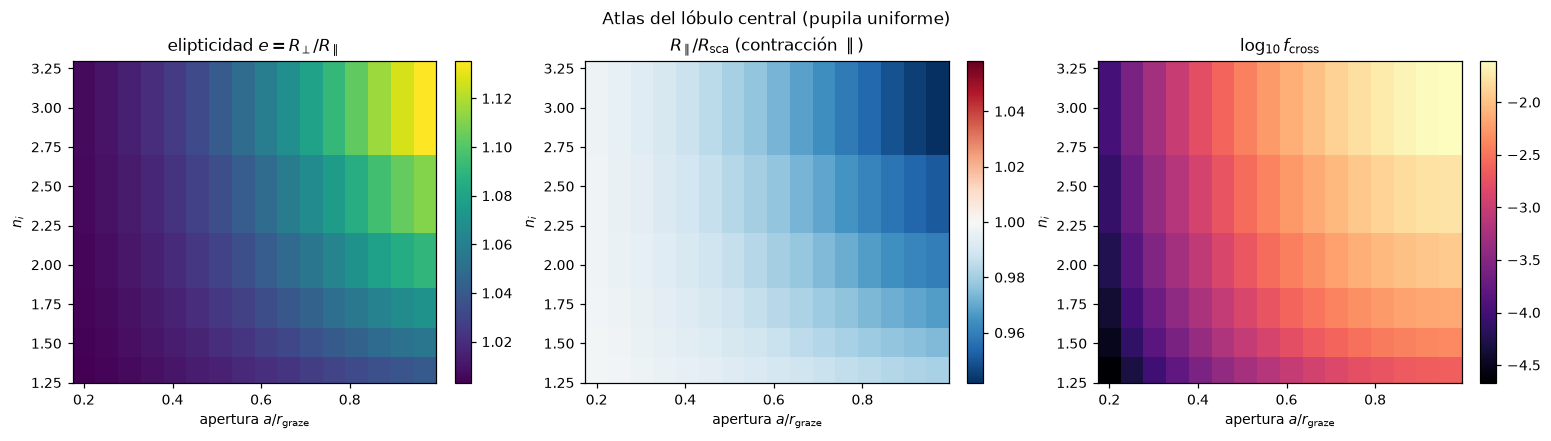

elipticidad máxima del atlas: e = 1.1356 (n_i=3, a=0.97 r_graze, α_obj=26.0°)


In [2]:
nis = np.array([1.33, 1.5, 1.7, 2.0, 2.4, 3.0])
fracs = np.linspace(0.2, 0.97, 16)

atlas = [[evaluate(st.spot_case(ni=ni, a_frac=fr, n_r=600, n_q=400, **base))
          for fr in fracs] for ni in nis]
get = lambda key: np.array([[m[key] for m in row] for row in atlas])

fig, axes = plt.subplots(1, 3, figsize=(14, 3.9), constrained_layout=True)
maps = [
    (get("ellipticity"), r"elipticidad $e=R_\perp/R_\parallel$", "viridis", None),
    (get("R_par") / get("R_sca"), r"$R_\parallel/R_{\rm sca}$ (contracción $\parallel$)", "RdBu_r", 1.0),
    (np.log10(get("f_cross")), r"$\log_{10} f_{\rm cross}$", "magma", None),
]
for ax, (Z, title, cmap, center) in zip(axes, maps):
    kw = {}
    if center is not None:
        d = np.abs(Z - center).max()
        kw = dict(vmin=center - d, vmax=center + d)
    pcm = ax.pcolormesh(fracs, nis, Z, shading="auto", cmap=cmap, **kw)
    ax.set(xlabel=r"apertura $a/r_{\rm graze}$", ylabel=r"$n_i$", title=title)
    fig.colorbar(pcm, ax=ax, fraction=0.046)
fig.suptitle("Atlas del lóbulo central (pupila uniforme)", fontsize=11)
fig.savefig(out_dir / "03_atlas.png", dpi=200)
plt.show()

i_max = np.unravel_index(np.argmax(get("ellipticity")), get("ellipticity").shape)
print(f"elipticidad máxima del atlas: e = {get('ellipticity')[i_max]:.4f} "
      f"(n_i={nis[i_max[0]]:g}, a={fracs[i_max[1]]:.2f} r_graze, "
      f"α_obj={get('alpha_obj_deg')[i_max]:.1f}°)")

La deformación crece monótonamente con apertura e índice, igual que
$f_{\rm cross}$. Nótese que $R_\parallel/R_{\rm sca}<1$ en casi todo el
atlas: **a lo largo de la polarización el campo vectorial resuelve mejor
que el escalar**, con el costo simétrico en la dirección ortogonal.

## 2. ¿Gobierna $f_{\rm cross}$ la deformación? Tres familias de pupilas

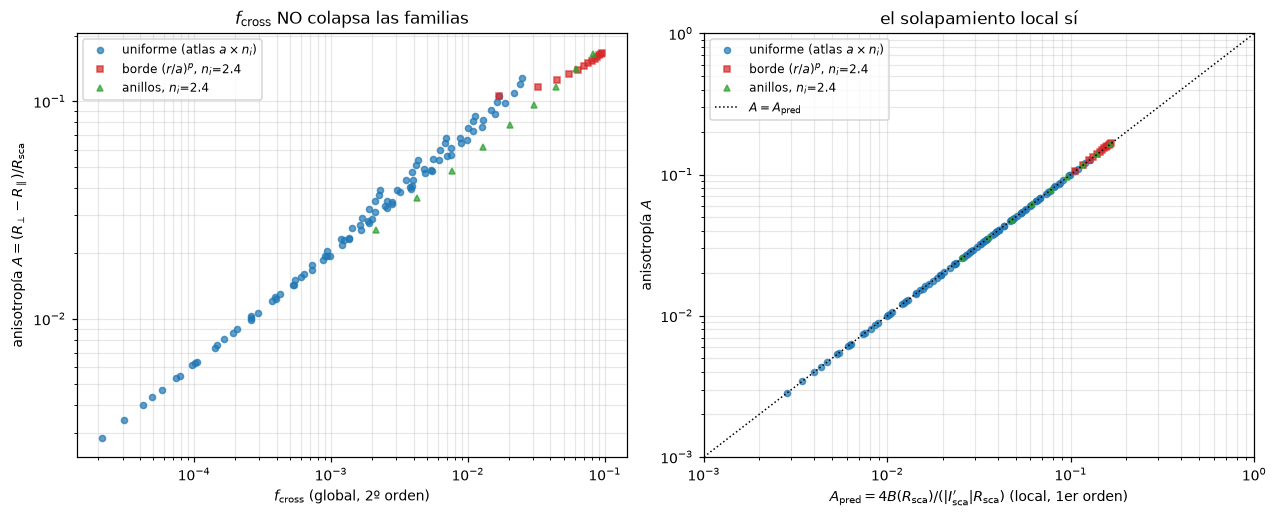

uniforme (atlas $a\times n_i$)  : mediana |A_pred/A - 1| = 0.000   máx = 0.006
borde $(r/a)^p$, $n_i$=2.4      : mediana |A_pred/A - 1| = 0.010   máx = 0.013
anillos, $n_i$=2.4              : mediana |A_pred/A - 1| = 0.003   máx = 0.013


In [3]:
# familia 2: peso de borde (r/a)^p sobre el dioptrio de alto índice
powers = np.arange(0, 13)
edge = [evaluate(st.spot_case(ni=2.4, a_frac=0.97, n_r=600, n_q=400,
                              pupil=lambda rr, p=p: (rr / rr[-1]) ** p, **base))
        for p in powers]

# familia 3: anillos supergaussianos de distintas posiciones (alto índice)
centers = np.linspace(0.35, 0.92, 9)
rings = [evaluate(st.spot_case(ni=2.4, a_frac=0.97, n_r=800, n_q=400,
                               pupil=lambda rr, c0=c0: np.exp(-(((rr - c0 * rr[-1]) / (0.08 * rr[-1])) ** 8)),
                               **base))
         for c0 in centers]

flat_atlas = [m for row in atlas for m in row]
families = [
    (flat_atlas, "uniforme (atlas $a\\times n_i$)", "o", "C0"),
    (edge, r"borde $(r/a)^p$, $n_i$=2.4", "s", "C3"),
    (rings, r"anillos, $n_i$=2.4", "^", "C2"),
]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6), constrained_layout=True)
for fam, label, marker, color in families:
    f = np.array([m["f_cross"] for m in fam])
    A = np.array([m["anisotropy"] for m in fam])
    Ap = np.array([m["A_pred"] for m in fam])
    axes[0].plot(f, A, marker, color=color, ms=4, alpha=0.7, ls="none", label=label)
    axes[1].plot(Ap, A, marker, color=color, ms=4, alpha=0.7, ls="none", label=label)

axes[0].set(xscale="log", yscale="log", xlabel=r"$f_{\rm cross}$ (global, 2º orden)",
            ylabel=r"anisotropía $A=(R_\perp-R_\parallel)/R_{\rm sca}$",
            title=r"$f_{\rm cross}$ NO colapsa las familias")
lim = [1e-3, 1.0]
axes[1].plot(lim, lim, "k:", lw=1, label=r"$A=A_{\rm pred}$")
axes[1].set(xscale="log", yscale="log", xlim=lim, ylim=lim,
            xlabel=r"$A_{\rm pred}=4B(R_{\rm sca})/(|I_{\rm sca}'|R_{\rm sca})$ (local, 1er orden)",
            ylabel=r"anisotropía $A$", title="el solapamiento local sí")
for ax in axes:
    ax.grid(alpha=0.3, which="both")
    ax.legend(fontsize=8)
fig.savefig(out_dir / "03_correlation.png", dpi=200)
plt.show()

for fam, label, *_ in families:
    A = np.array([m["anisotropy"] for m in fam])
    Ap = np.array([m["A_pred"] for m in fam])
    ok = np.isfinite(A) & np.isfinite(Ap) & (A > 0)
    err = np.abs(Ap[ok] / A[ok] - 1.0)
    print(f"{label:32s}: mediana |A_pred/A - 1| = {np.median(err):.3f}   máx = {err.max():.3f}")

## 3. La familia de borde en detalle: superresolución $\parallel$ y su precio

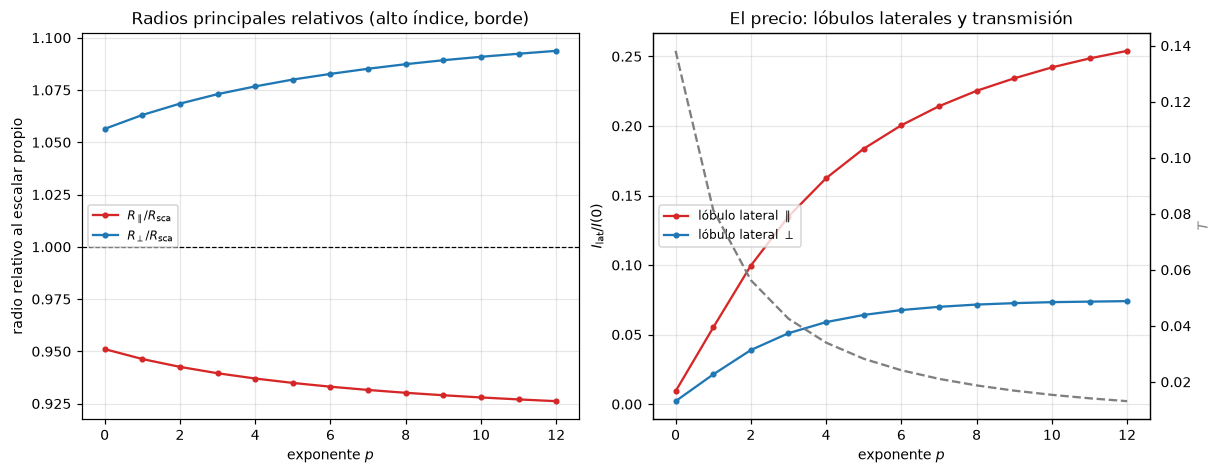

In [4]:
R_par_rel = np.array([m["R_par"] / m["R_sca"] for m in edge])
R_perp_rel = np.array([m["R_perp"] / m["R_sca"] for m in edge])
side_par = np.array([m["sidelobe_par"] for m in edge])
side_perp = np.array([m["sidelobe_perp"] for m in edge])
T_edge = [st.transmission(st.spot_case(ni=2.4, a_frac=0.97, n_r=600, n_q=16,
                                       pupil=lambda rr, p=p: (rr / rr[-1]) ** p, **base))
          for p in powers]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
axes[0].plot(powers, R_par_rel, "C3o-", ms=3, label=r"$R_\parallel/R_{\rm sca}$")
axes[0].plot(powers, R_perp_rel, "C0o-", ms=3, label=r"$R_\perp/R_{\rm sca}$")
axes[0].axhline(1.0, color="k", lw=0.8, ls="--")
axes[0].set(xlabel=r"exponente $p$", ylabel="radio relativo al escalar propio",
            title="Radios principales relativos (alto índice, borde)")

axes[1].plot(powers, side_par, "C3o-", ms=3, label=r"lóbulo lateral $\parallel$")
axes[1].plot(powers, side_perp, "C0o-", ms=3, label=r"lóbulo lateral $\perp$")
ax2 = axes[1].twinx()
ax2.plot(powers, T_edge, "C7--", label="transmisión $T$")
ax2.set_ylabel("$T$", color="C7")
axes[1].set(xlabel=r"exponente $p$", ylabel=r"$I_{\rm lat}/I(0)$",
            title="El precio: lóbulos laterales y transmisión")
for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc="center left")
fig.savefig(out_dir / "03_edge_detail.png", dpi=200)
plt.show()

## 4. Incidencia circular: ensanchamiento de 2º orden

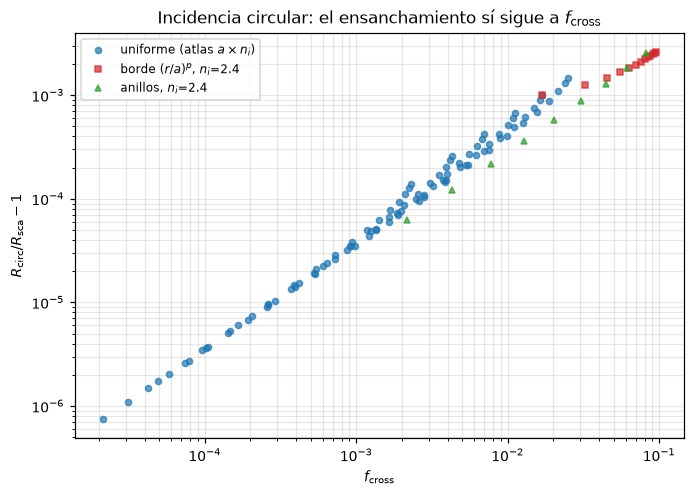

In [5]:
fig, ax = plt.subplots(figsize=(6.2, 4.4), constrained_layout=True)
for fam, label, marker, color in families:
    f = np.array([m["f_cross"] for m in fam])
    dR = np.array([m["R_circ"] / m["R_sca"] - 1.0 for m in fam])
    ax.plot(f, dR, marker, color=color, ms=4, alpha=0.7, ls="none", label=label)
ax.set(xscale="log", yscale="log", xlabel=r"$f_{\rm cross}$",
       ylabel=r"$R_{\rm circ}/R_{\rm sca}-1$",
       title=r"Incidencia circular: el ensanchamiento sí sigue a $f_{\rm cross}$")
ax.grid(alpha=0.3, which="both")
ax.legend(fontsize=8)
fig.savefig(out_dir / "03_circular_broadening.png", dpi=200)
plt.show()

## Conclusiones

1. **Tamaño**: respecto del escalar con la misma pupila, el lóbulo vectorial
   con polarización lineal se contrae a lo largo de la polarización
   ($R_\parallel/R_{\rm sca}<1$) y se expande en la ortogonal, en casi todo
   el rango explorado; la elipticidad crece con apertura, índice y peso de
   borde (hasta $e\sim 1.2$ en los extremos explorados).
2. **El descriptor correcto de la deformación no es $f_{\rm cross}$** sino
   el solapamiento local $B(R_{\rm sca})=\mathrm{Re}(H_0H_2^*)$ en el radio
   de mitad de altura: el predictor de primer orden $A_{\rm pred}$ colapsa
   las tres familias de pupilas; $f_{\rm cross}$ deja separación clara entre
   familias (es un descriptor global de 2º orden).
3. **Circular vs. lineal**: con incidencia circular no hay término de primer
   orden; el punto queda simétrico y su ensanchamiento (2º orden) sí
   correlaciona directamente con $f_{\rm cross}$.
4. La maximización de la cruzada por peso de borde compra elipticidad y
   contracción $\parallel$ pagando lóbulos laterales y transmisión.

## Hoja de ruta

- **Campo longitudinal**: incluir $|E_z|^2$ (via `vecdiff.longitudinal`) y
  repetir las métricas; en alto NA suele invertir la dirección de
  elongación.
- **Imagen de dos dioptrios**: propagar estas métricas al plano imagen del
  sistema formador (conexión con `resolution_inversion.py`).
- **Polarizaciones no homogéneas** (radial/azimutal, base `polar`): allí el
  canal $J_2$ se reemplaza por $J_1$ y el análisis cambia.
- **Fuera de foco**: dependencia axial de los radios principales.